In [229]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp

# Problem 1

Recall that we previously showed that, for the SIR model with a constant reqruitment rate $\Lambda$ and per-capita mortality rate $\mu$

$$\begin{gather}\dot S =& \Lambda - \beta SI - \mu S\\
\dot I =& \beta SI - (\gamma + \mu)I \\
\dot R =& \gamma I - \mu R\end{gather}$$

the total population size $N = S + I + R$ follows $\dot N = \lambda - \mu N$ and thus $S+I+R=\lambda/\mu$ defines an attracting (locally $\mathbb{R}^2$) invariant manifold embeded in $\mathbb{R}^3$. Let us restrict our focus here to the dynamics within the invariant manifold, given by $R=\Lambda/\mu -S-I$ (so $S_0 + I_o \leq\Lambda\mu$) and

$$\begin{align*}\dot S =&\; \Lambda - \beta SI - \mu S\\
\dot I =&\; \beta SI - (\gamma + \mu)I \end{align*}$$

## a)

The basic reproduction number for this model can be shown to be $\mathcal{R}_0=\frac{\beta\Lambda/\mu}{\gamma + \mu}$. Use $\tau = (\gamma + \mu)t$, with $(x,y)=\left(\frac{\beta}{\gamma + \mu}S,\frac{\beta}{\gamma+\mu}I\right)$, and $r=\frac{\mu}{\mu + \gamma}$ to show that the above system can be written as 

$$\begin{align*}\dot x =&\; r(\mathcal{R}_0 -x) -xy \\
\dot y =&\; (x-1)y \end{align*}$$

---

$$\begin{align}\dot x =&\; r(\mathcal{R}_0 -x) -xy \\
\dot y =&\; (x-1)y\end{align}$$

Subbing in values for $(x,y)$

$$\begin{gather}\frac{d}{dt}  \left[\frac{\beta}{\gamma + \mu}S\right]  =&\; r(\mathcal{R}_0 -\left[\frac{\beta}{\gamma + \mu}S\right]) -\left[\frac{\beta}{\gamma + \mu}S\right]\left[\frac{\beta}{\gamma + \mu}I\right] \\
\frac{d}{dt} \left[\frac{\beta}{\gamma + \mu}I\right] =&\; (\left[\frac{\beta}{\gamma + \mu}S\right]-1)\left[\frac{\beta}{\gamma + \mu}I\right]\end{gather}$$

Doing algebra

$$\begin{align*}\dot S  =&\; r\left(\frac{\gamma + \mu}{\beta}\mathcal{R}_0 -S\right) -\frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \left(\frac{\beta}{\gamma + \mu}S-1\right)I\end{align*}$$

Plugging in $\mathcal{R}_0=\frac{\beta\Lambda/\mu}{\gamma + \mu}$

$$\begin{align*}\dot S  =&\; r\left(\frac{\Lambda}{\mu} -S\right) -\frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \left(\frac{\beta}{\gamma + \mu}S-1\right)I\end{align*}$$

Plugging in $r=\frac{\mu}{\mu + \gamma}$

$$\begin{align*}\dot S  =&\; \frac{\Lambda}{\mu + \gamma}  - \frac{\mu}{\mu + \gamma}S - \frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \frac{\beta}{\gamma + \mu}SI-I\end{align*}$$

Considering the time derivative with respect to $\tau = (\gamma + \mu)t$

$$\boxed{\begin{align*}\dot S  =&\; \Lambda  - \mu S - \beta SI\\
\dot I =&\; \beta SI-I(\gamma + \mu)\end{align*}}$$


## b)

The disease free equilibrium (DFE) for this system is $(\mathcal{R}_0,0)$. Evaluate the corresponding Jacobian and show that the DFE becomes non-hyperbolic when $\mathcal{R}_0=1$ (that is, treating $\mathcal{R}_0$ as a parameter, a bifurcation likely occurs at $\mathcal{R_0}=1$).

---

In [230]:
r, R, x, y = smp.symbols(r'r \mathcal{R}_0 x y')

dx = r*(R-x)-x*y
dy = (x-1)*y

In [231]:
eq1 = smp.solve([dx,dy],[x,y])[0]
eq1

(\mathcal{R}_0, 0)

In [232]:
eq2 = smp.solve([dx,dy],[x,y])[1]
eq2

(-(-\mathcal{R}_0*r + r*(\mathcal{R}_0 - 1))/r, r*(\mathcal{R}_0 - 1))

In [233]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])
Jac

Matrix([
[-r - y,    -x],
[     y, x - 1]])

In [234]:
J0 = Jac.subs([[x,R],[y,0]])
# J0 = Jac.subs([[x,0],[y,0],[R,0]])
J0

Matrix([
[-r,    -\mathcal{R}_0],
[ 0, \mathcal{R}_0 - 1]])

In [235]:
eigs0 = J0.subs(R,0).eigenvects()
eigs0

[(-1,
  1,
  [Matrix([
   [0],
   [1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

In [236]:
eigs1 = J0.subs(R,1).eigenvects()
eigs1

[(0,
  1,
  [Matrix([
   [-1/r],
   [   1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

In [237]:
eigs2 = J0.subs(R,2).eigenvects()
eigs2

[(1,
  1,
  [Matrix([
   [-2/(r + 1)],
   [         1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

## c)


Do a center manifold reduction of equations 1 about the DFE and $\mathcal{R}_0=1$

---

First shifting the dynamics so the bifurcation point is at the origin

In [238]:
dx = -r*x - (1+R + x)*y
dy = (R+x)*y

Evaluating the eigen-stuff at the origin

In [239]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])
Jac

Matrix([
[-r - y, -\mathcal{R}_0 - x - 1],
[     y,      \mathcal{R}_0 + x]])

In [240]:
J0 = Jac.subs([[x,0],[y,0],[R,0]])
J0

Matrix([
[-r, -1],
[ 0,  0]])

In [241]:
eigs1 = J0.eigenvects()
eigs1

[(0,
  1,
  [Matrix([
   [-1/r],
   [   1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

Defining variables for the eigen-space, and transfering to it

In [242]:
c, s = smp.symbols('c s')

cs = smp.Matrix([[c],[s]])
X  = smp.Matrix([[x],[y]])
dX = smp.Matrix([[dx],[dy]])

In [243]:
vc = eigs1[0][2][0]
vs = eigs1[1][2][0]

V  = smp.Matrix([vc.T,vs.T]).T
VT = V.T

In [244]:
X_cs = V@cs
X_cs

Matrix([
[-c/r + s],
[       c]])

In [245]:
dcs = VT@dX
dcs

Matrix([
[y*(\mathcal{R}_0 + x) - (-r*x - y*(\mathcal{R}_0 + x + 1))/r],
[                            -r*x - y*(\mathcal{R}_0 + x + 1)]])

In [246]:
dcs = dcs.subs([[x,X_cs[0]],[y,X_cs[1]]])
dc = dcs[0].expand()
ds = dcs[1].expand()

In [247]:
dc

\mathcal{R}_0*c + \mathcal{R}_0*c/r - c**2/r - c**2/r**2 + c*s + c*s/r + s

In [248]:
ds

-\mathcal{R}_0*c + c**2/r - c*s - r*s

Isolating the linear part of the dynamics

In [249]:
A = dc.coeff(c,1).coeff(s,0)
A 

\mathcal{R}_0 + \mathcal{R}_0/r

In [250]:
g1 = dc - A*c
g1.expand()

-c**2/r - c**2/r**2 + c*s + c*s/r + s

In [251]:
B = ds.coeff(c,0).coeff(s,1)
B 

-r

In [252]:
g2 = ds - B*s
g2.expand()

-\mathcal{R}_0*c + c**2/r - c*s

Forming the $h$ and $\mathcal{N}$ eqauations

In [253]:
a1, a2, a3 = smp.symbols('a_1 a_2 a_3')

h  = a1*c**2 + a2*c*R + a3*R**2
dh = smp.diff(h,c)
dh

\mathcal{R}_0*a_2 + 2*a_1*c

In [254]:
N = dh*(A*c + g1) - B*h - g2
N = N.subs(s,h).expand()
N

\mathcal{R}_0**3*a_2*a_3*c + \mathcal{R}_0**3*a_2*a_3*c/r + \mathcal{R}_0**3*a_2*a_3 + 2*\mathcal{R}_0**2*a_1*a_3*c**2 + 2*\mathcal{R}_0**2*a_1*a_3*c**2/r + 2*\mathcal{R}_0**2*a_1*a_3*c + \mathcal{R}_0**2*a_2**2*c**2 + \mathcal{R}_0**2*a_2**2*c**2/r + \mathcal{R}_0**2*a_2**2*c + \mathcal{R}_0**2*a_2*c + \mathcal{R}_0**2*a_2*c/r + \mathcal{R}_0**2*a_3*c + \mathcal{R}_0**2*a_3*r + 3*\mathcal{R}_0*a_1*a_2*c**3 + 3*\mathcal{R}_0*a_1*a_2*c**3/r + 3*\mathcal{R}_0*a_1*a_2*c**2 + 2*\mathcal{R}_0*a_1*c**2 + 2*\mathcal{R}_0*a_1*c**2/r + \mathcal{R}_0*a_2*c**2 - \mathcal{R}_0*a_2*c**2/r - \mathcal{R}_0*a_2*c**2/r**2 + \mathcal{R}_0*a_2*c*r + \mathcal{R}_0*c + 2*a_1**2*c**4 + 2*a_1**2*c**4/r + 2*a_1**2*c**3 + a_1*c**3 - 2*a_1*c**3/r - 2*a_1*c**3/r**2 + a_1*c**2*r - c**2/r

Isolating coefficients and solving for their condition that lower power terms go to 0

In [255]:
coeff_c2 = N.coeff(c,2).coeff(R,0)
coeff_c2

a_1*r - 1/r

In [256]:
coeff_R2 = N.coeff(c,0).coeff(R,2)
coeff_R2

a_3*r

In [257]:
coeff_cR = N.coeff(c,1).coeff(R,1)
coeff_cR

a_2*r + 1

In [258]:
coeff = smp.solve([coeff_c2,coeff_R2,coeff_cR],[a1,a2,a3])
coeff

{a_1: r**(-2), a_3: 0, a_2: -1/r}

In [259]:
h_fill = h.subs([[a1,coeff[a1]],
                 [a2,coeff[a2]],
                 [a3,coeff[a3]]]).expand()
h_fill

-\mathcal{R}_0*c/r + c**2/r**2

In [260]:
dc_fill = dc.subs(s,h_fill).expand()
dc_fill

-\mathcal{R}_0*c**2/r - \mathcal{R}_0*c**2/r**2 + \mathcal{R}_0*c + c**3/r**2 + c**3/r**3 - c**2/r

## d)

Analyze the resulting 1-dimensional dynamics on the center manifold to show that a transcritical bifurcation is occurring at $\mathcal{R}_0=1$. Note: this can be a simple graphical analysis of that center manifold equation, or a comparison with bifurcation normal forms. You do not need to do a full normal form calculation for this step!! If you are unable to complete part (c) above, please consult with your instructor about how to proceed with part (d).

---

In [261]:
dc_fill.subs(r,1)

-2*\mathcal{R}_0*c**2 + \mathcal{R}_0*c + 2*c**3 - c**2

In [262]:
dc_func = smp.lambdify([R,c],dc_fill.subs(r,1))

def dR_func(R,c):
    return 0

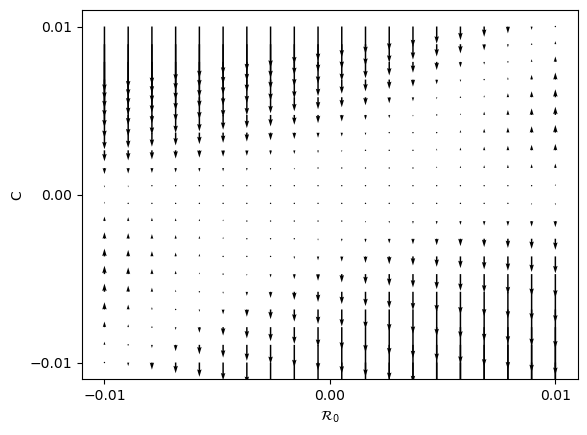

In [269]:
Rv = np.linspace(-0.01,0.01,20)
cv = np.linspace(-0.01,0.01,20)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))

plt.yticks([-0.01,0,0.01])
plt.xticks([-0.01,0,0.01])
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

plt.savefig(f'./figs/p1d_transBifur.png',transparent=True, dpi=300, bbox_inches='tight')

# Problem 2

Recall the period doubling cascade to chaos in the logistic map

$$x_{n+1}=rx_n(1-x_n)$$

In ecological modeling, researchers sometimes use a more flexible version of the continuous time logistic equation $\dot N = rN(1-N/K)$ ̇(or if we set $x=N/K$, $\dot x = rx(1-x)$) known as the theta-logistic model: $\dot x = rx(1-x^\theta)$. Here $\theta > 0$ gives us a longer initial exponential growth phase, while $\theta \in (0,1)$ causes a stronger nonlinear effect and dampens exponential growth sooner than in the logistic case ($\theta = 1$).

Your goal is to look at the dynamics of the analogous map, which we’ll call the theta-logistic map:

$$x_{n+1} = rx_n(1-x_n^\theta)$$

## a)

Show that in the continuous time theta-logistic model,

$$\dot x = rx(1-x^\theta)$$

 the local asymptotic stability of $x=0$ and of $x=1$ are not affected by the choice of $\theta$ since we require $\theta>0$.

---

Take the continuous time model as

$$\begin{align*}f(x) =&\; rx(1-x^\theta)\\
=&\; rx - rx^{\theta+1}\end{align*}$$

Then the derivative is 

$$\begin{align*}f'(x) =&\; r - r(\theta + 1) x^{\theta}\end{align*}$$

For $x=0$

$$\begin{align*}f'(0) =&\; r - r(\theta + 1) 0^{\theta}\\
=&\; r \end{align*}$$

So the stability at $x=0$ is independent of $\theta$. For $x=1$

$$\begin{align*}f'(1) =&\; r - r(\theta + 1) 1^{\theta}\\
&\; r - r(\theta + 1) \\
&\; - r\theta \end{align*}$$

Since $\theta>0$, the stability at $x=1$ is again not changed by the magnitude of $\theta$

## b)

Code the bifurcation diagram for the logistic map. Generate the analogous bifurcation diagram for some $\theta\in(0,1)$ and some $\theta>1$. **Show all three bifurcation diagrams in your solution, and discuss wow changing $\theta$ above or below $1$ seems to change the bifurcation structure**.

---

In [264]:
from numpy.random import random

In [265]:
theta1 = 0.4
theta2 = 1
theta3 = 1.9

r_set = np.arange(0.8,8,0.0001)
steps = 500
X0 = 2


X1 = []
X2 = []
X3 = []
for r in r_set:
    x1 = X0*random()
    x2 = x1
    x3 = x1
    for n in range(steps):
        x1 = r*x1*(1-x1**theta1)
        x2 = r*x2*(1-x2**theta2)
        x3 = r*x3*(1-x3**theta3)
        
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)

/tmp/ipykernel_63285/3945434757.py:18: RuntimeWarning: invalid value encountered in scalar power
  x1 = r*x1*(1-x1**theta1)
/tmp/ipykernel_63285/3945434757.py:20: RuntimeWarning: invalid value encountered in scalar power
  x3 = r*x3*(1-x3**theta3)
/tmp/ipykernel_63285/3945434757.py:19: RuntimeWarning: overflow encountered in scalar multiply
  x2 = r*x2*(1-x2**theta2)


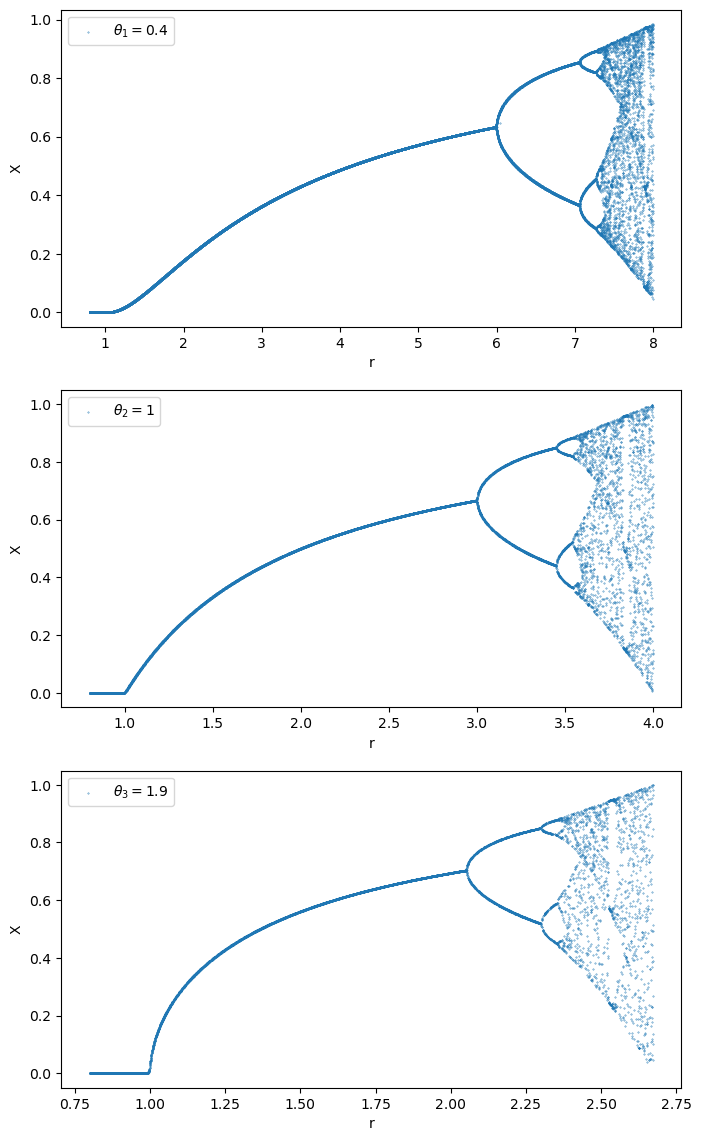

In [270]:
fig, (p1,p2,p3) = plt.subplots(3,1,figsize=(8,14))


p1.scatter(r_set,X1,s=0.1,label=fr'$\theta_1=${theta1}')
p1.legend()
p1.set_ylabel('X')
p1.set_xlabel('r')



p2.scatter(r_set,X2,s=0.1,label=fr'$\theta_2=${theta2}')
p2.legend()
p2.set_ylabel('X')
p2.set_xlabel('r')



p3.scatter(r_set,X3,s=0.1,label=fr'$\theta_3=${theta3}')
p3.legend()
p3.set_ylabel('X')
p3.set_xlabel('r')


plt.savefig(f'./figs/p2b_logMap.png',transparent=True, dpi=300, bbox_inches='tight')

## c)

To add some analytical results to these computational findings, one could analyze the various period doubling bifurcations and their dependence on $\theta$. Find the fixed point (analogous to the single fixed point that exists for $r>1$ in the logistic map), and determine it’s stability conditions for $r>1$ and $\theta>0$. Recall that, for a 1D map, the Jacobian is just the $1\times 1$ diagonal matrix (that is, the scalar) $f'(x_{eq})$. Also recall the corresponding eigenvalue condition at a flip bifurcation. **Find where the fixed point of the theta-logistic map loses stability via a flip bifurcation, and discuss how this threshold is shifted by increasing or decreasing $\theta$ relative to $\theta = 1$. Discuss this in the context of your numerical results for part (b) above.**

---

$$\begin{align*}f(\bar{x})=&\;\bar{x}\\
\bar{x}=&\;r\bar{x}(1-(\bar{x})^\theta)\\
1 =&\; r(1-(\bar{x})^\theta)\\
\frac{1}{r} =&\; 1-\bar{x}^\theta\\
\bar{x}^\theta =&\; 1-\frac{1}{r}\end{align*}$$

Resulting in the fixed point

$$\boxed{\begin{align*}\\
\bar{x} =&\; \left(1-\frac{1}{r}\right)^{1/\theta}\end{align*}}$$

Taking the derivative 

$$\begin{align*}f'(x)=&\; r-r(\theta+1)x^\theta\\
\end{align*}$$

Evaluating at $\bar{x}$

$$\begin{align*}f'(\bar{x})=&\; r-r(\theta+1)\bar{x}^\theta\\
=&\; r-r(\theta + 1)\left(1 - \frac{1}{r}\right)\\
=&\; r - r\left(\theta - \theta\frac{1}{r} + 1 - \frac{1}{r}\right)\\
=&\; 1 - r\theta + \theta \end{align*}$$



The stability condition is $|f'(\bar{x})|<1$ so

$$\begin{align*}-1 < 1 - r\theta + \theta < 1\\
-1 - \theta < 1 - r\theta  < 1 - \theta\\
-2 - \theta <  - r\theta  <  - \theta\end{align*}$$

Giving the stability window

$$\boxed{\begin{align*}1<   r  < \frac{2}{\theta} + 1\end{align*}}$$


For the flip bifurcation $f'(\bar{x})=-1$

$$\begin{align*}-1 =&\; 1 - r\theta + \theta\\
\frac{-2}{\theta} =&\;  - r + 1\\
r =&\; 1 + \frac{2}{\theta}\end{align*}$$

There is a flip bifurcation for

$$\boxed{\begin{align*}r = 1 + \frac{2}{\theta}\end{align*}}$$


For the flip bifurcation $f'(\bar{x})=-1$

$$\begin{align*}-1 =&\; 1 - r\theta + \theta\\
\frac{-2}{\theta} =&\;  - r + 1\\
r =&\; 1 + \frac{2}{\theta}\end{align*}$$

There is a flip bifurcation for

$$\boxed{\begin{align*}r = 1 + \frac{2}{\theta}\end{align*}}$$


In [267]:
theta1 = 0.4
theta2 = 1
theta3 = 1.9

r1_flip = 1 + 2/theta1
r2_flip = 1 + 2/theta2
r3_flip = 1 + 2/theta3

x1_bif = (1-1/r1_flip)**(1/theta1)
x2_bif = (1-1/r2_flip)**(1/theta2)
x3_bif = (1-1/r3_flip)**(1/theta3)

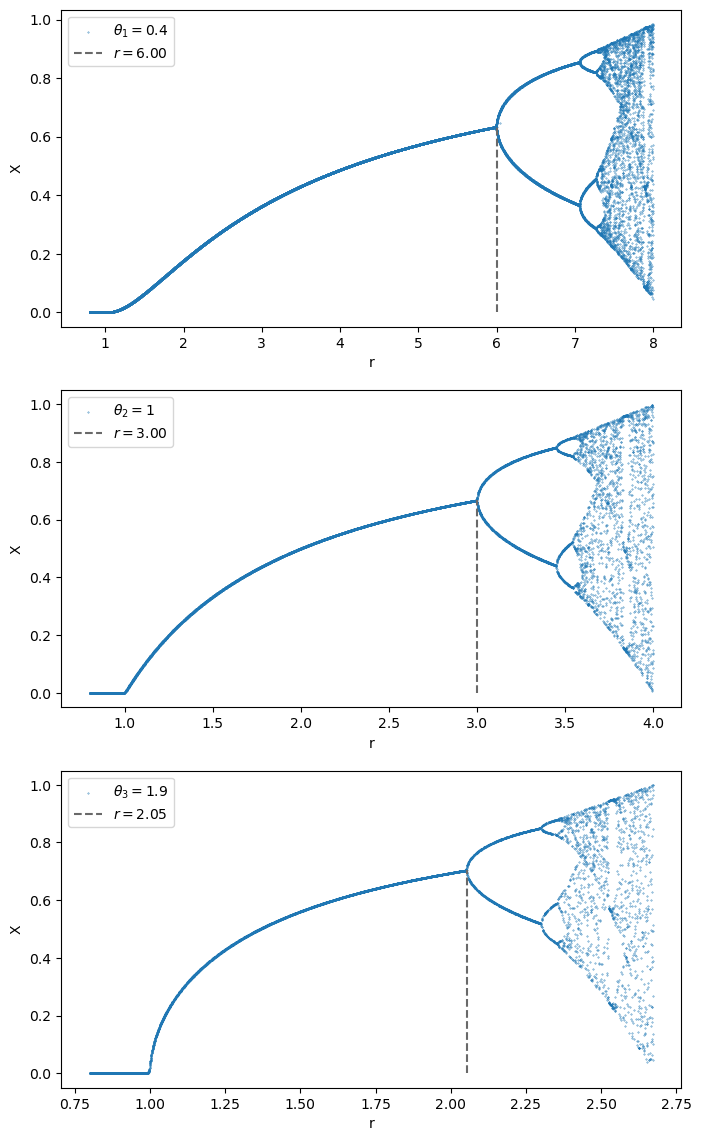

In [271]:
fig, (p1,p2,p3) = plt.subplots(3,1,figsize=(8,14))


p1.scatter(r_set,X1,s=0.1,label=fr'$\theta_1=${theta1}')
p1.vlines(r1_flip,ymin=0,ymax=x1_bif,
          linestyle='--',color='dimgray',label=fr'$r =${r1_flip:.2f}')
p1.legend()
p1.set_ylabel('X')
p1.set_xlabel('r')


p2.scatter(r_set,X2,s=0.1,label=fr'$\theta_2=${theta2}')
p2.vlines(r2_flip,ymin=0,ymax=x2_bif,
          linestyle='--',color='dimgray',label=fr'$r =${r2_flip:.2f}')
p2.legend()
p2.set_ylabel('X')
p2.set_xlabel('r')


p3.scatter(r_set,X3,s=0.1,label=fr'$\theta_3=${theta3}')
p3.vlines(r3_flip,ymin=0,ymax=x3_bif,
          linestyle='--',color='dimgray',label=fr'$r =${r3_flip:.2f}')
p3.legend()
p3.set_ylabel('X')
p3.set_xlabel('r')

plt.savefig(f'./figs/p2c_pdub.png',transparent=True, dpi=300, bbox_inches='tight')